In [17]:
import torch
import torch.nn as nn
import numpy as np
import mido
import matplotlib.pyplot as plt
from music21 import *


In [5]:
device = 'cpu'
base_dir = '/Users/annie/Documents/Shimon-Counterpoint/cocotorch/'

In [6]:
# load training data
data = np.load(base_dir + 'Jsb16thSeparated.npz', encoding='bytes', allow_pickle=True)

In [7]:
# transpose chorales to different keys, so there's more variation in training data
all_tracks = []
for x in data.files:
    for y in data[x]:
        for i in range(-6, 6):
            all_tracks.append(y + i)

print(len(all_tracks))

4584


In [8]:
# determine highest and lowest pitches

max_midi_pitch = -np.inf
min_midi_pitch = np.inf
for x in all_tracks:
    if x.max() > max_midi_pitch:
        max_midi_pitch = int(x.max())
    if x.min() < min_midi_pitch:
        min_midi_pitch = int(x.min())
        
print(max_midi_pitch, min_midi_pitch)

86 30


In [9]:
I = 4 # number of voices
T = 32 # length of samples (32 = two 4/4 measures)
P = max_midi_pitch - min_midi_pitch +1 # number of different pitches
batch_size=24

In [75]:
# function for converting arrays of shape (T, 4) into midi files
# the input array has entries that are np.nan (representing a rest)
# of an integer between 0 and 127 inclusive

def piano_roll_to_midi(piece):
    """
    piece is a an array of shape (T, 4) for some T.
    The (i,j)th entry of the array is the midi pitch of the jth voice at time i. It's an integer in range(128).
    outputs a mido object mid that you can convert to a midi file by called its .save() method
    """
    piece = np.concatenate([piece, [[np.nan, np.nan, np.nan, np.nan]]], axis=0)

    bpm = 40
    microseconds_per_beat = 60 * 1000000 / bpm

    mid = mido.MidiFile()
    tracks = {'soprano': mido.MidiTrack(), 'alto': mido.MidiTrack(),
              'tenor': mido.MidiTrack(), 'bass': mido.MidiTrack()}
    past_pitches = {'soprano': np.nan, 'alto': np.nan,
                    'tenor': np.nan, 'bass': np.nan}
    delta_time = {'soprano': 0, 'alto': 0, 'tenor': 0, 'bass': 0}

    # create a track containing tempo data
    metatrack = mido.MidiTrack()
    metatrack.append(mido.MetaMessage('set_tempo',
                                      tempo=int(microseconds_per_beat), time=0))
    mid.tracks.append(metatrack)

    # create the four voice tracks
    for voice in tracks:
        mid.tracks.append(tracks[voice])
        tracks[voice].append(mido.Message(
            'program_change', program=52, time=0))

    # add notes to the four voice tracks
    for i in range(len(piece)):
        pitches = {'soprano': piece[i, 0], 'alto': piece[i, 1],
                   'tenor': piece[i, 2], 'bass': piece[i, 3]}
        for voice in tracks:
            if np.isnan(past_pitches[voice]):
                past_pitches[voice] = None
            if np.isnan(pitches[voice]):
                pitches[voice] = None
            if pitches[voice] != past_pitches[voice]:
                if past_pitches[voice]:
                    tracks[voice].append(mido.Message('note_off', note=int(past_pitches[voice]),
                                                      velocity=80, time=delta_time[voice]))
                    delta_time[voice] = 0
                if pitches[voice]:
                    tracks[voice].append(mido.Message('note_on', note=int(pitches[voice]),
                                                      velocity=80, time=delta_time[voice]))
                    delta_time[voice] = 0
            past_pitches[voice] = pitches[voice]
            # 480 ticks per beat and each line of the array is a 16th note
            delta_time[voice] += 120

    return mid





class Chorale:
    """
    A class to store and manipulate an array self.arr that stores a chorale.
    """
    def __init__(self, arr, subtract_30=False):
        # arr is an array of shape (4, 32) with values in range(0, 57)
        self.arr = arr.copy()
        if subtract_30:
            self.arr -= 30
            
        # the one_hot representation of the array
        reshaped = self.arr.reshape(-1)
        self.one_hot = np.zeros((I*T, P))
        r = np.arange(I*T)
        self.one_hot[r, reshaped] = 1
        self.one_hot = self.one_hot.reshape(I, T, P)
        

    def to_image(self):
        # visualize the four tracks as a images
        soprano = self.one_hot[0].transpose()
        alto = self.one_hot[1].transpose()
        tenor = self.one_hot[2].transpose()
        bass = self.one_hot[3].transpose()
        
        fig, axs = plt.subplots(1, 4)
        axs[0].imshow(np.flip(soprano, axis=0), cmap='hot', interpolation='nearest')
        axs[0].set_title('soprano')
        axs[1].imshow(np.flip(alto, axis=0), cmap='hot', interpolation='nearest')
        axs[1].set_title('alto')
        axs[2].imshow(np.flip(tenor, axis=0), cmap='hot', interpolation='nearest')
        axs[2].set_title('tenor')
        axs[3].imshow(np.flip(bass, axis=0), cmap='hot', interpolation='nearest')
        axs[3].set_title('bass')
        fig.set_figheight(5)
        fig.set_figwidth(15)
        return fig, axs
    
    def save(self, filename='midi_track.mid'):
        # display an in-notebook widget for playing audio
        # saves the midi file as a file named name in base_dir/midi_files
        
        midi_arr = self.arr.transpose().copy()
        midi_arr += 30
        midi = piano_roll_to_midi(midi_arr)
        midi.save(base_dir + 'midi_files/' + filename)
        #play_midi('midi_files/' + filename)
        
    def elaborate_on_voices(self, voices, model):
        # voice is a set consisting of 0, 1, 2, or 3
        # create a mask consisting of the given voices
        # generate a chorale with the same voices as in voices
        mask = np.zeros((I, T))
        y = np.random.randint(P, size=(I, T))
        for i in voices:
            mask[i] = 1
            y[i] = self.arr[i].copy()
        return harmonize(y, mask, model)

    def score(self):
        consonance_dict = {0: 1, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 0, 7: 1, 8: 1, 9: 1, 10: 0, 11: 0}
        consonance_score = 0
        for k in range(32):
            for i in range(4):
                for j in range(i):
                    consonance_score += consonance_dict[((self.arr[i, k] - self.arr[j, k]) % 12)]
        
        note_score = 0
        for i in range(4):
            for j in range(1, 32):
                if self.arr[i, j] != self.arr[i, j-1]:
                    note_score += 1
        return consonance_score, note_score
        
        
        
        
# harmonize a melody
def harmonize(y, C, model):
    """
    Generate an artificial Bach Chorale starting with y, and keeping the pitches where C==1.
    Here C is an array of shape (4, 32) whose entries are 0 and 1.
    The pitches outside of C are repeatedly resampled to generate new values.
    For example, to harmonize the soprano line, let y be random except y[0] contains the soprano line, let C[1:] be 0 and C[0] be 1.
    """
    model.eval()
    with torch.no_grad():
        x = y
        C2 = C.copy()
        num_steps = int(2*I*T)
        alpha_max = .999
        alpha_min = .001
        eta = 3/4
        for i in range(num_steps):
            p = np.maximum(alpha_min, alpha_max - i*(alpha_max-alpha_min)/(eta*num_steps))
            sampled_binaries = np.random.choice(2, size = C.shape, p=[p, 1-p])
            C2 += sampled_binaries
            C2[C==1] = 1
            x_cache = x
            x = model.pred(x, C2)
            x[C2==1] = x_cache[C2==1]
            C2 = C.copy()
        return x
    
def generate_random_chorale(model):
    """
    Calls harmonize with random initialization and C=0, and so generates a new sample that sounds like Bach.
    """
    y = np.random.randint(P, size=(I, T)).astype(int)
    C = np.zeros((I, T)).astype(int)
    return harmonize(y, C, model)

In [11]:
hidden_size = 32

class Unit(nn.Module):
    """
    Two convolution layers each followed by batchnorm and relu, plus a residual connection.
    """
    def __init__(self):
        super(Unit, self).__init__()
        self.conv1 = nn.Conv2d(hidden_size, hidden_size, 3, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(hidden_size)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(hidden_size, hidden_size, 3, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(hidden_size)
        self.relu2 = nn.ReLU()
        
        
    def forward(self, x):
        y = x
        y = self.conv1(y)
        y = self.batchnorm1(y)
        y = self.relu1(y)
        y = self.conv2(y)
        y = self.batchnorm2(y)
        y = y + x
        y = self.relu2(y)
        return y
    

class Net(nn.Module):
    """
    A CNN that where you input a starter chorale and a mask and it outputs a prediction for the values
    in the starter chorale away from the mask that are most like the training data.
    """
    def __init__(self):
        super(Net, self).__init__()
        self.initial_conv = nn.Conv2d(2*I, hidden_size, 3, padding=1)
        self.initial_batchnorm = nn.BatchNorm2d(hidden_size)
        self.initial_relu = nn.ReLU()
        self.unit1 = Unit()
        self.unit2 = Unit()
        self.unit3 = Unit()
        self.unit4 = Unit()
        self.unit5 = Unit()
        self.unit6 = Unit()
        self.unit7 = Unit()
        self.unit8 = Unit()
        self.unit9 = Unit()
        self.unit10 = Unit()
        self.unit11 = Unit()
        self.unit12 = Unit()
        self.unit13 = Unit()
        self.unit14 = Unit()
        self.unit15 = Unit()
        self.unit16 = Unit()
        self.affine = nn.Linear(hidden_size*T*P, I*T*P)
        
    def forward(self, x, C):
        # x is a tensor of shape (N, I, T, P)
        # C is a tensor of 0s and 1s of shape (N, I, T)
        # returns a tensor of shape (N, I, T, P)
        
        # get the number of batches
        N = x.shape[0]
        
        # tile the array C out of a tensor of shape (N, I, T, P)
        tiled_C = C.view(N, I, T, 1)
        tiled_C = tiled_C.repeat(1, 1, 1, P)
        
        # mask x and combine it with the mask to produce a tensor of shape (N, 2*I, T, P)
        y = torch.cat((tiled_C*x, tiled_C), dim=1)
        
        # apply the convolution and relu layers
        y = self.initial_conv(y)
        y = self.initial_batchnorm(y)
        y = self.initial_relu(y)
        y = self.unit1(y)
        y = self.unit2(y)
        y = self.unit3(y)
        y = self.unit4(y)
        y = self.unit5(y)
        y = self.unit6(y)
        y = self.unit7(y)
        y = self.unit8(y)
        y = self.unit9(y)
        y = self.unit10(y)
        y = self.unit11(y)
        y = self.unit12(y)
        y = self.unit13(y)
        y = self.unit14(y)
        y = self.unit15(y)
        y = self.unit16(y)
            
        # reshape before applying the fully connected layer
        y = y.view(N, hidden_size*T*P)
        y = self.affine(y)
        
        # reshape to (N, I, T, P)
        y = y.view(N, I, T, P)
                
        return y
    
    def pred(self, y, C):
        # y is an array of shape (I, T) with integer entries in [0, P)
        # C is an array of shape (I, T) consisting of 0s and 1s
        # the entries of y away from the support of C should be considered 'unknown'
        
        # x is shape (I, T, P) one-hot representation of y
        compressed = y.reshape(-1)
        x = np.zeros((I*T, P))
        r = np.arange(I*T)
        x[r, compressed] = 1
        x = x.reshape(I, T, P)
        
        # prep x and C for the plugging into the model
        x = torch.tensor(x).type(torch.FloatTensor).to(device)
        x = x.view(1, I, T, P)
        C2 = torch.tensor(C).type(torch.FloatTensor).view(1, I, T).to(device)
        
        # plug x and C2 into the model
        with torch.no_grad():
            out = self.forward(x, C2).view(I, T, P).cpu().numpy()
            out = out.transpose(2, 0, 1) # shape (P, I, T)
            probs = np.exp(out) / np.exp(out).sum(axis=0) # shape (P, I, T)
            cum_probs = np.cumsum(probs, axis=0) # shape (P, I, T)
            u = np.random.rand(I, T) # shape (I, T)
            return np.argmax(cum_probs > u, axis=0)     



In [12]:
model = Net().to(device)

In [13]:
model.load_state_dict(torch.load(base_dir + 'CocoNetModel.pt', map_location=torch.device('cpu')))

<All keys matched successfully>

In [38]:
def format_melody(melody):
    
    if len(melody) > 32:
        melody = melody[:32]  # Truncate the list if it's too long
    elif len(melody) < 32:
        melody = melody + [0] * (32 - len(melody))  # Pad the list with zeros if it's too short
    return melody

In [67]:
def read_midi(input_dir):
    
    """
        Arg: 
            input_dir: path to midi file to read
        Return:
            melody: list of pitch values in the midi file
    """ 

    midi_stream = converter.parse(input_dir)
    melody = []
    for note in midi_stream.flat.notes:
        pitch = note.pitch.midi
        dur = note.duration.quarterLength
        if dur == 0.25:
            melody.extend([pitch] * 1)
        elif dur == 0.5:
            melody.extend([pitch] * 2)
        elif dur == 0.75:
            melody.append(pitch * 3)
        elif dur == 1.0:
            melody.extend([pitch] * 4)
        elif dur == 1.25:
            melody.extend([pitch] * 5)   
        elif dur == 1.5:
            melody.extend([pitch] * 6)
        elif dur == 1.75:
            melody.extend([pitch] * 7)
        elif dur == 2:
            melody.extend([pitch] * 8)
        elif dur == 2.25:
            melody.extend([pitch] * 9)
        elif dur == 2.5:
            melody.extend([pitch] * 10)
        elif dur == 2.75:
            melody.extend([pitch] * 11)
        elif dur == 3:
            melody.extend([pitch] * 12)
        elif dur == 3.25:
            melody.extend([pitch] * 13)
        elif dur == 3.5:
            melody.extend([pitch] * 14)
        elif dur == 3.75:
            melody.extend([pitch] * 15)  
        elif dur == 4.0:
            melody.extend([pitch] * 16)        
        
    melody = format_melody(melody)
    
    return melody

In [70]:
def get_avg_pitch(melody = []):
    
    if len(melody) == 0:
        return 0
    else:
        return sum(melody) / len(melody)

In [71]:
melody = read_midi('/Users/annie/Documents/Shimon-Counterpoint/cocotorch/test_input_midi/01.mid')
print(melody)

[67, 69, 72, 69, 64, 64, 62, 64, 67, 67, 69, 69, 69, 69, 69, 69, 67, 67, 64, 65, 64, 64, 67, 67, 69, 69, 67, 64, 67, 67, 60, 60]


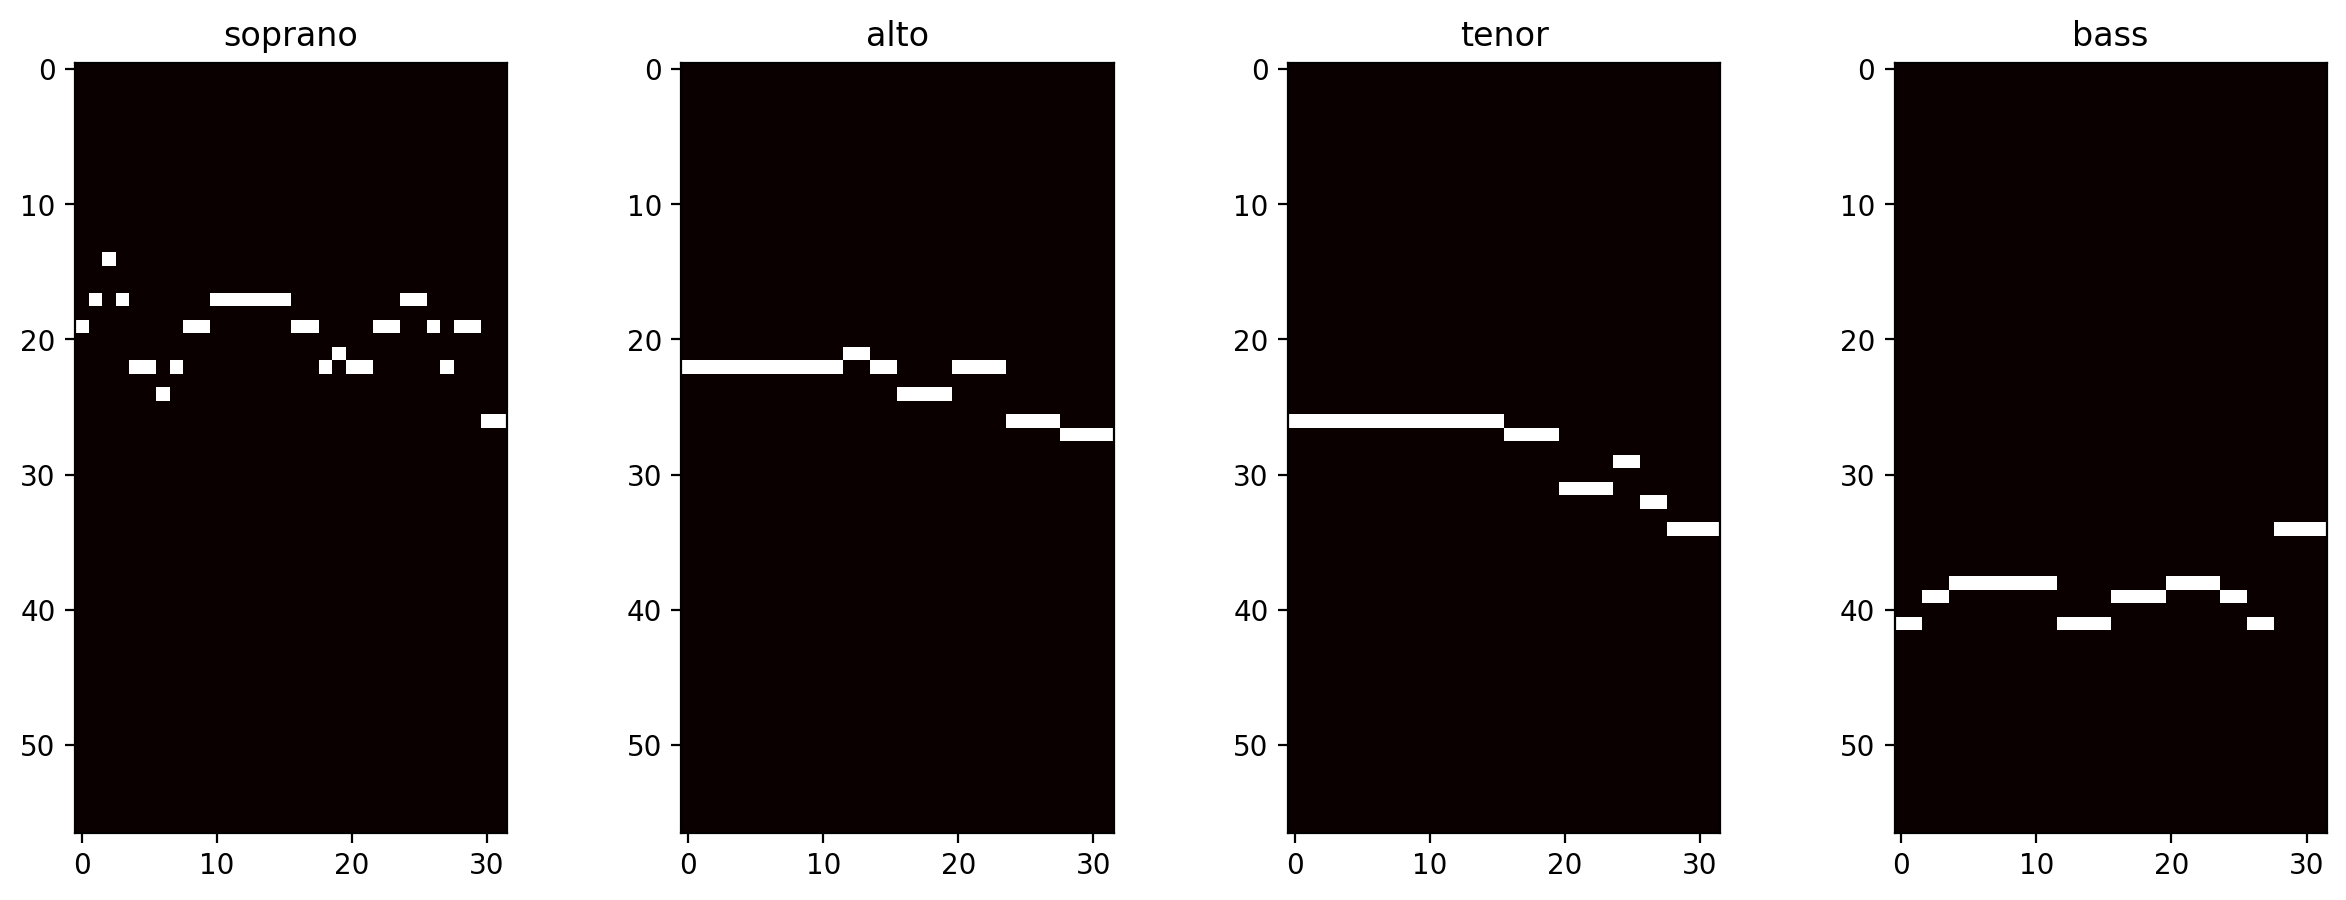

In [73]:
# let's try harmonizing a simple melody as soprano

melody = read_midi('/Users/annie/Documents/Shimon-Counterpoint/cocotorch/test_input_midi/01.mid')

y = np.random.randint(P, size=(I, T))
y[0] = np.array(melody)-30
D0 = np.ones((1, T)).astype(int)
D1 = np.zeros((3, T)).astype(int)
D = np.concatenate([D0, D1], axis=0)


chorale = Chorale(harmonize(y, D, model))
chorale.to_image()
plt.show()
chorale.save()

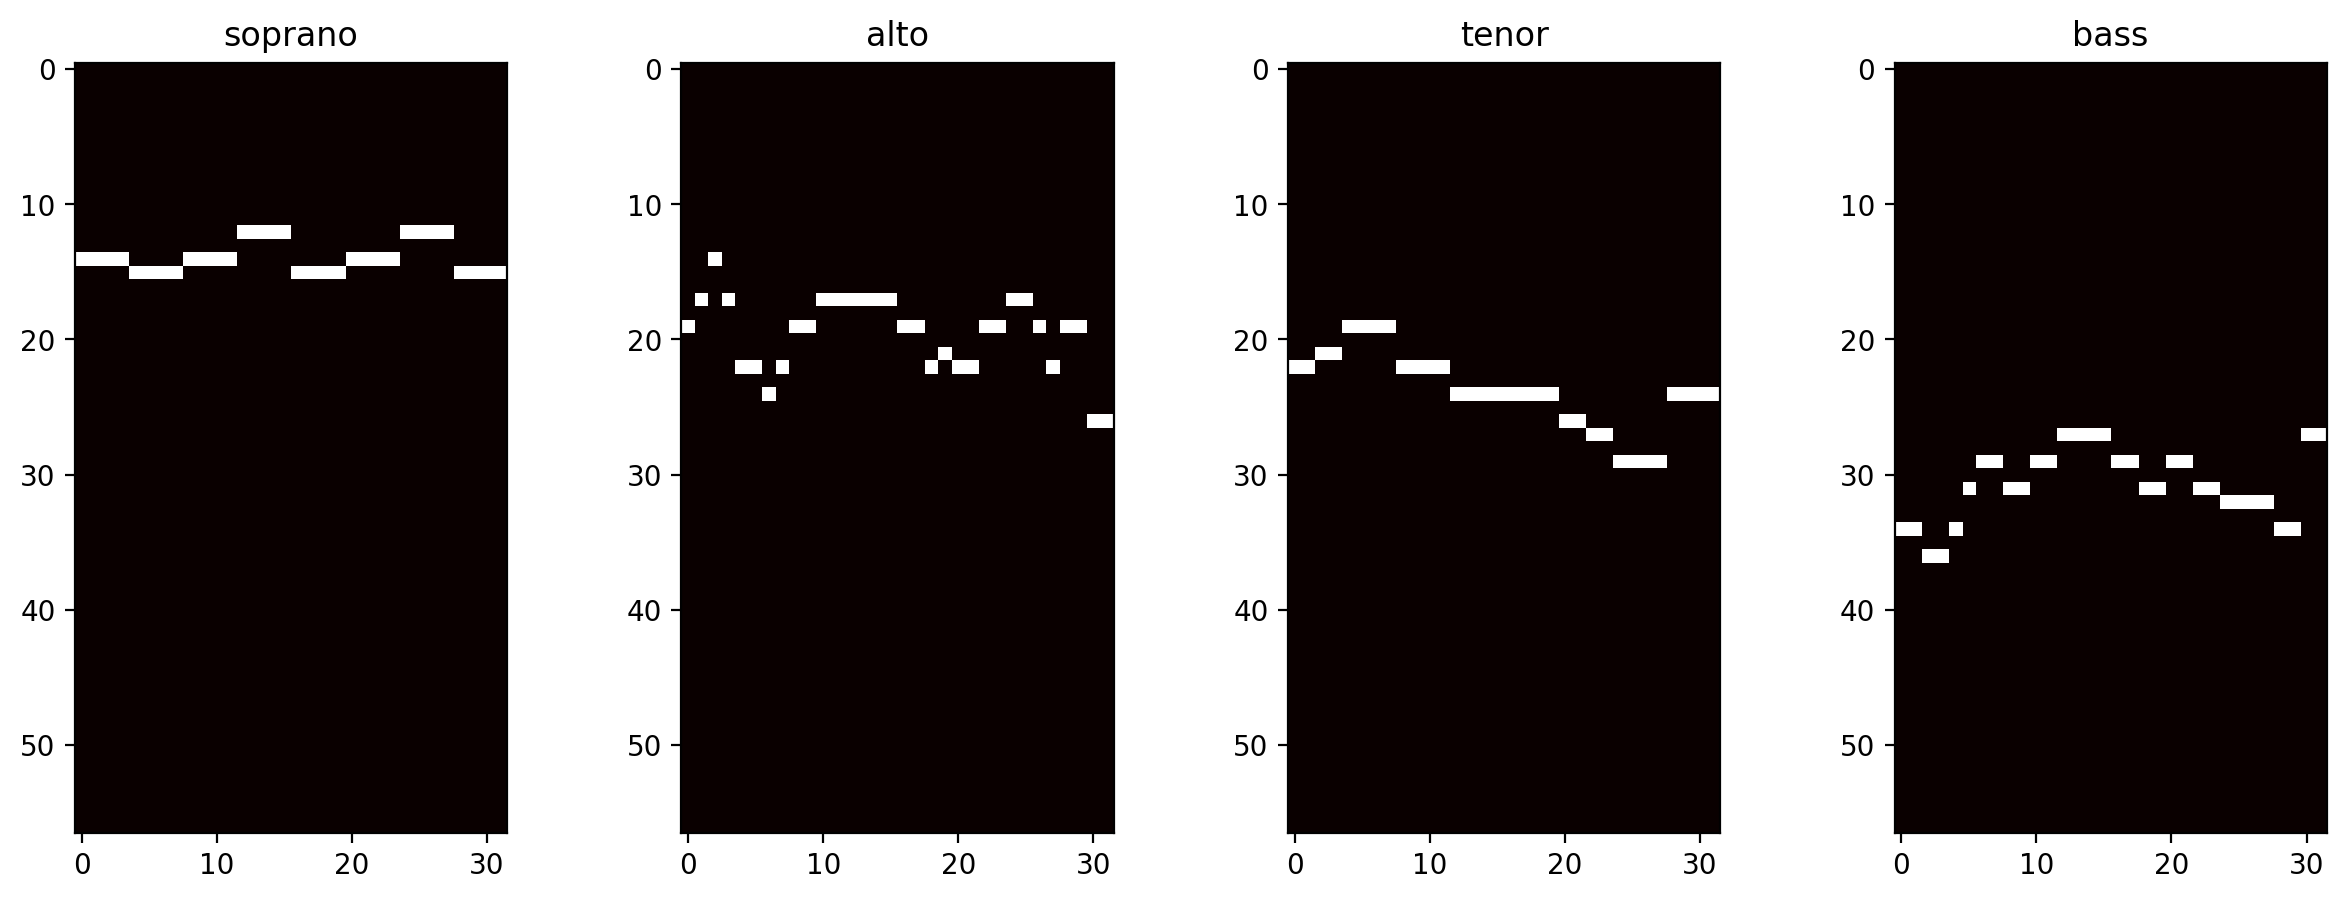

In [76]:
# let's try harmonizing a simple melody as alto

melody = read_midi('/Users/annie/Documents/Shimon-Counterpoint/cocotorch/test_input_midi/01.mid')

y = np.random.randint(P, size=(I, T))
y[1] = np.array(melody)-30
D0 = np.zeros((1, T)).astype(int)
D1 = np.ones((1, T)).astype(int)
D2 = np.zeros((2, T)).astype(int)
D1 = np.concatenate([D0, D1], axis=0)
D = np.concatenate([D1, D2], axis=0)


chorale = Chorale(harmonize(y, D, model))
chorale.to_image()
plt.show()
chorale.save()